# Tutorial 2 — Inferring the **richness–mass relation** by hierarchical reuse

In **Tutorial 1** the population was just a mean $\mu$ and a scatter $\tau$. Here the population prior is a
full **relation** between two cluster observables — the **richness–mass relation** — and we infer its
*shape* (slope, intercept, scatter) by **reusing each cluster's weak-lensing (WL) mass posterior**.

This is exactly the cluster **mass-calibration** problem. It also delivers a crucial, slightly subtle lesson:

> **Reusing WL mass posteriors is *not* enough on its own.** To infer a mass–observable relation you must
> fold in the **mass distribution** (the interim/population prior) — otherwise you reproduce the classic
> *regression-dilution / Eddington* bias. We will see all three cases side by side.

> Setup (same as Tutorial 1): `pip install "numpy<2" emcee "matplotlib<3.9"`

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(11)

def run_mcmc(log_post, start, n_walkers=16, n_burn=1000, n_steps=2000):
    # Generic emcee wrapper -> returns flat samples of shape (n_walkers*n_steps, n_dim).
    n_dim = len(start)
    p0 = start + 0.03 * np.random.randn(n_walkers, n_dim)
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_post)
    state = sampler.run_mcmc(p0, n_burn, progress=False)
    sampler.reset()
    sampler.run_mcmc(state, n_steps, progress=False)
    return sampler.get_chain(flat=True)

print("emcee", emcee.__version__, "| numpy", np.__version__)

emcee 3.1.6 | numpy 1.26.4


## 1. The richness–mass relation (the population model)

Let $x=\log_{10}(M/M_{\rm pivot})$ be the (log) mass and $y=\log_{10}\lambda$ the (log) richness. The relation
is a straight line with intrinsic scatter:

$$y \;=\; a \;+\; b\,x \;+\; \varepsilon,\qquad \varepsilon\sim\mathcal N(0,\sigma^2).$$

The **hyperparameters** we want are $\Lambda=(a,b,\sigma)$: the intercept $a$, slope $b$, and intrinsic
scatter $\sigma$. Each cluster also has a noisy **weak-lensing mass**, which gives a *posterior* on its $x$.

In [2]:
# --- TRUE relation we will try to recover ---
a_true, b_true, sigma_true = 1.60, 1.00, 0.10     # intercept, slope, intrinsic scatter (in log10 lambda)

# --- the mass distribution: where the clusters' TRUE (log) masses live ---
#     In a real analysis this is the halo mass function folded through the selection.
#     Here: a Gaussian of width sigma_mass about the pivot.  We treat it as KNOWN.
sigma_mass = 0.30        # spread of true log-masses (dex)

# --- weak-lensing mass measurement noise (per cluster) ---
sigma_WL = 0.25          # 1-sigma WL uncertainty on log-mass (individual clusters are noisy!)

n_clusters = 120
print("true relation:  y = %.2f + %.2f x  with scatter %.2f" % (a_true, b_true, sigma_true))
print("mass distribution width = %.2f dex,  WL mass error = %.2f dex" % (sigma_mass, sigma_WL))

true relation:  y = 1.60 + 1.00 x  with scatter 0.10
mass distribution width = 0.30 dex,  WL mass error = 0.25 dex


## 2. Simulate a cluster sample

For each cluster we draw a true mass from the mass distribution, compute its true richness from the relation
(plus intrinsic scatter), and then make a **noisy WL measurement** of the mass.

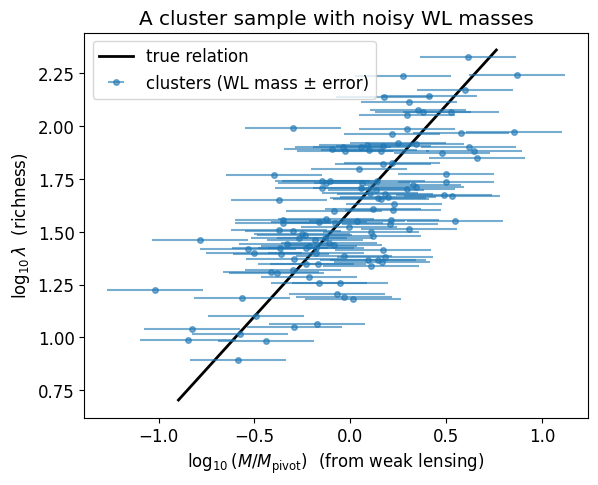

In [3]:
x_true = sigma_mass * np.random.randn(n_clusters)                       # true log-mass  x_j
y_obs  = a_true + b_true * x_true + sigma_true * np.random.randn(n_clusters)  # observed richness  y_j
x_wl   = x_true + sigma_WL * np.random.randn(n_clusters)                # WL point estimate of the mass

plt.figure(figsize=(6.5, 5))
grid = np.linspace(x_true.min()-0.1, x_true.max()+0.1, 50)
plt.plot(grid, a_true + b_true*grid, "k-", lw=2, label="true relation")
plt.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=4, color="tab:blue", alpha=0.6,
             label="clusters (WL mass ± error)")
plt.xlabel(r"$\log_{10}(M/M_{\rm pivot})$  (from weak lensing)")
plt.ylabel(r"$\log_{10}\lambda$  (richness)")
plt.title("A cluster sample with noisy WL masses"); plt.legend(); plt.show()

## 3. The per-cluster WL mass posteriors (the stored samples)

A real WL pipeline gives, for each cluster, a *posterior* on its mass — not a single number. Here, with a
flat interim prior, that posterior is $p(x_j\mid d_j)=\mathcal N(x_j^{\rm WL},\sigma_{\rm WL}^2)$. We draw
$S$ samples from it. **These stand in for the posterior samples Akum's pipeline saves for each cluster.**

In [4]:
n_samples = 3000
# wl_samples[j] is the set of S posterior samples of the (log) mass for cluster j.
wl_samples = x_wl[:, None] + sigma_WL * np.random.randn(n_clusters, n_samples)
print("wl_samples shape =", wl_samples.shape, " (clusters x posterior-samples)")

wl_samples shape = (120, 3000)  (clusters x posterior-samples)


## 4. Attempt 1 — fit the relation to the **point** WL masses (biased)

The obvious thing is to fit a straight line to $(x_j^{\rm WL},\,y_j)$ with ordinary least squares. This is
**biased**: because the $x$-values carry measurement error, the fitted slope is *attenuated* (pulled toward
zero). This is **regression dilution / errors-in-variables**. The expected attenuation factor is

$$\hat b_{\rm naive}\;\approx\; b\,\frac{\sigma_{\rm mass}^2}{\sigma_{\rm mass}^2+\sigma_{\rm WL}^2}.$$

In [5]:
b_naive, a_naive = np.polyfit(x_wl, y_obs, 1)                  # OLS slope & intercept
sigma_naive = (y_obs - (a_naive + b_naive * x_wl)).std()       # residual scatter

attenuation = sigma_mass**2 / (sigma_mass**2 + sigma_WL**2)
print("naive OLS :  a = %.2f   b = %.2f   sigma = %.3f" % (a_naive, b_naive, sigma_naive))
print("expected attenuated slope  b * %.2f = %.2f  (true b = %.2f)" % (attenuation, b_true*attenuation, b_true))
print(" -> slope pulled DOWN, scatter pushed UP (the WL error leaks into both).")

naive OLS :  a = 1.60   b = 0.59   sigma = 0.215
expected attenuated slope  b * 0.59 = 0.59  (true b = 1.00)
 -> slope pulled DOWN, scatter pushed UP (the WL error leaks into both).


## 5. Attempt 2 — importance-sampling **reuse** with a flat prior (still biased!)

Now we do it "properly" with the cluster posteriors. The hierarchical model is

$$x_j\sim p(x)\ \text{(mass distribution)},\qquad y_j\mid x_j\sim\mathcal N(a+bx_j,\sigma^2),\qquad d_j\mid x_j\ \text{(WL data)} .$$

The hyper-posterior marginalises each cluster's latent mass:

$$p(\Lambda\mid\{d_j,y_j\})\ \propto\ p(\Lambda)\prod_j\int p(d_j\mid x_j)\,p(y_j\mid x_j,\Lambda)\,p(x_j)\,dx_j .$$

Using stored samples $x_j^{(s)}\sim p(x_j\mid d_j)\propto p(d_j\mid x_j)\,\pi(x_j)$ (interim prior $\pi$), the
**reuse identity** is

$$\int p(d_j\mid x)\,p(y_j\mid x,\Lambda)\,p(x)\,dx\ \approx\ \frac{Z_j}{S}\sum_s p\big(y_j\mid x_j^{(s)},\Lambda\big)\,\frac{p(x_j^{(s)})}{\pi(x_j^{(s)})}.$$

**Attempt 2 ignores the weight** $p(x)/\pi(x)$ (i.e. pretends $p(x)\propto\pi$, a flat mass prior) and just
averages $\mathcal N(y_j;a+bx_j^{(s)},\sigma^2)$ over the samples. Watch what happens.

In [6]:
def log_post_reuse_flat(params):
    a, b, log_sigma = params
    sigma = np.exp(log_sigma)
    if sigma > 2:
        return -np.inf
    total = 0.0
    for j in range(n_clusters):
        # probability of this cluster's richness for each stored mass sample, then average:
        richness_density = np.exp(-0.5 * ((y_obs[j] - (a + b * wl_samples[j])) / sigma)**2) / sigma
        total += np.log(richness_density.mean() + 1e-300)
    return total + log_sigma     # + log_sigma : Jacobian for sampling in log(sigma)

chain_flat = run_mcmc(log_post_reuse_flat, start=np.array([a_true, b_true, np.log(sigma_true)]))
a_f, b_f, s_f = chain_flat[:, 0], chain_flat[:, 1], np.exp(chain_flat[:, 2])
print("reuse, FLAT prior :  a = %.2f   b = %.2f   sigma = %.3f" % (a_f.mean(), b_f.mean(), s_f.mean()))
print(" -> SAME biased slope as naive OLS.  Reusing the posteriors did not, by itself, help.")

reuse, FLAT prior :  a = 1.60   b = 0.60   sigma = 0.158
 -> SAME biased slope as naive OLS.  Reusing the posteriors did not, by itself, help.


**Why it's still biased.** The flat-prior WL samples for cluster $j$ are centred on its noisy estimate
$x_j^{\rm WL}$, so averaging over them is almost the same as using the point mass — the regression dilution
survives. The missing ingredient is the **mass distribution** $p(x)$: clusters scattered to high apparent
mass are intrinsically rarer, so their masses should be **shrunk** back. That shrinkage is the
$p(x)/\pi(x)$ weight.

## 6. Attempt 3 — reuse **+ the mass distribution** (the correct HBI)

Put the weight back. With a flat interim prior $\pi$, the weight is just the **mass distribution**
$p(x_j^{(s)})=\mathcal N(x_j^{(s)};0,\sigma_{\rm mass}^2)$:

$$\ln\mathcal L(\Lambda)=\sum_j\ln\!\Big[\frac1S\sum_s \mathcal N\!\big(y_j;a+bx_j^{(s)},\sigma^2\big)\,
   \underbrace{\mathcal N\!\big(x_j^{(s)};0,\sigma_{\rm mass}^2\big)}_{\text{mass distribution }=\,p(x)/\pi(x)}\Big].$$

This re-weights each cluster's WL samples toward where clusters actually live, undoing the dilution.

In [7]:
def log_post_reuse_massdist(params):
    a, b, log_sigma = params
    sigma = np.exp(log_sigma)
    if sigma > 2:
        return -np.inf
    total = 0.0
    for j in range(n_clusters):
        richness_density = np.exp(-0.5 * ((y_obs[j] - (a + b * wl_samples[j])) / sigma)**2) / sigma
        mass_prior       = np.exp(-0.5 * (wl_samples[j] / sigma_mass)**2)   # p(x): the mass distribution
        total += np.log((richness_density * mass_prior).mean() + 1e-300)
    return total + log_sigma

chain_md = run_mcmc(log_post_reuse_massdist, start=np.array([a_true, b_true, np.log(sigma_true)]))
a_m, b_m, s_m = chain_md[:, 0], chain_md[:, 1], np.exp(chain_md[:, 2])
print("reuse + mass distribution :  a = %.2f±%.2f   b = %.2f±%.2f   sigma = %.3f±%.3f"
      % (a_m.mean(), a_m.std(), b_m.mean(), b_m.std(), s_m.mean(), s_m.std()))
print(" -> recovers the TRUE relation (a=%.2f, b=%.2f, sigma=%.2f)." % (a_true, b_true, sigma_true))

reuse + mass distribution :  a = 1.60±0.02   b = 1.00±0.08   sigma = 0.098±0.042
 -> recovers the TRUE relation (a=1.60, b=1.00, sigma=0.10).


## 7. Putting it together

                            a       b       sigma
truth                  :  1.60    1.00    0.100
naive OLS (points)     :  1.60    0.59    0.215   <- biased
reuse, flat prior      :  1.60    0.60    0.158   <- still biased
reuse + mass dist.     :  1.60    1.00    0.098   <- correct


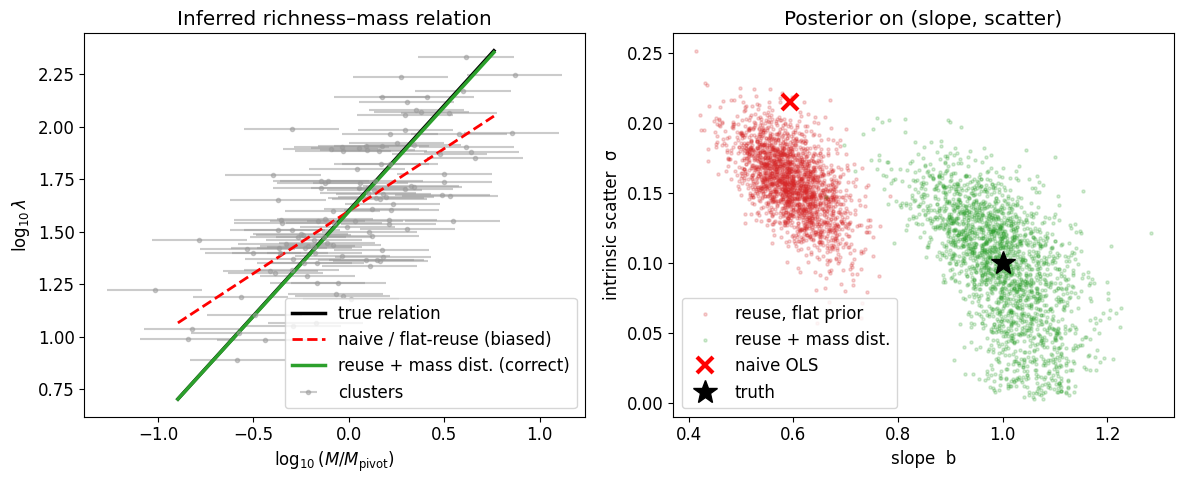

In [8]:
print("                            a       b       sigma")
print("truth                  :  %.2f    %.2f    %.3f" % (a_true, b_true, sigma_true))
print("naive OLS (points)     :  %.2f    %.2f    %.3f   <- biased" % (a_naive, b_naive, sigma_naive))
print("reuse, flat prior      :  %.2f    %.2f    %.3f   <- still biased" % (a_f.mean(), b_f.mean(), s_f.mean()))
print("reuse + mass dist.     :  %.2f    %.2f    %.3f   <- correct" % (a_m.mean(), b_m.mean(), s_m.mean()))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))
# left: the data with the true line, the biased naive line, and the correct reuse line
grid = np.linspace(x_true.min()-0.1, x_true.max()+0.1, 50)
axL.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=3, color="0.6", alpha=0.5, label="clusters")
axL.plot(grid, a_true + b_true*grid,        "k-",  lw=2.5, label="true relation")
axL.plot(grid, a_naive + b_naive*grid,      "r--", lw=2,   label="naive / flat-reuse (biased)")
axL.plot(grid, a_m.mean() + b_m.mean()*grid,"-",   lw=2.5, color="tab:green", label="reuse + mass dist. (correct)")
axL.set_xlabel(r"$\log_{10}(M/M_{\rm pivot})$"); axL.set_ylabel(r"$\log_{10}\lambda$")
axL.set_title("Inferred richness–mass relation"); axL.legend()

# right: the (slope, scatter) posteriors -- flat-reuse misses the truth, reuse+massdist contains it
axR.scatter(b_f[::15], s_f[::15], s=5, alpha=0.2, color="tab:red",   label="reuse, flat prior")
axR.scatter(b_m[::15], s_m[::15], s=5, alpha=0.2, color="tab:green", label="reuse + mass dist.")
axR.plot(b_naive, sigma_naive, "rx", ms=12, mew=3, label="naive OLS")
axR.plot(b_true, sigma_true, "k*", ms=18, label="truth")
axR.set_xlabel("slope  b"); axR.set_ylabel("intrinsic scatter  σ")
axR.set_title("Posterior on (slope, scatter)"); axR.legend()
plt.tight_layout(); plt.show()

## 8. What this means for the real pipeline, and summary

**Connection to Akum's code.** The per-cluster `wl_samples[j]` here are exactly the **weak-lensing mass
posterior samples** the pipeline produces for each cluster. The mass distribution $p(x)$ is the **halo mass
function folded through the richness selection** (the same ingredients already in `populationutils.py`).
Drop those two things in and the *same* reuse code infers the richness–mass relation $(a,b,\sigma)$ — with
**no re-fitting of any cluster**.

**Takeaways.**
1. A population prior can be a **full relation** (slope, intercept, scatter), not just a mean and a scatter.
2. **Importance-sampling reuse** of stored per-cluster posteriors lets you infer that relation cheaply.
3. **But the interim/population prior matters.** Reusing WL posteriors with a *flat* mass prior keeps the
   **regression-dilution (Eddington) bias** — the slope comes out too shallow and the scatter too large.
   Re-weighting by the **mass distribution** $p(x)/\pi(x)$ fixes it and recovers the truth.
4. This is the general lesson behind the reuse identity: the weight $p(\theta\mid\Lambda)/\pi(\theta)$ is not
   optional — it is how the population model enters.

*Caveat for a real analysis:* we treated the mass distribution as known. In practice you would either use the
mass function for the selection, or infer its parameters jointly with $(a,b,\sigma)$.